# 01_02 — Statistiche idrometri: soglie, contesto prima del rosso, Aree per potenziale uso dati satellitari

Notebook ripulito dal `01_01_sensor_stats`. Ordine: import → funzioni → percorsi → caricamento ed elaborazione → statistiche → grafici → cross-correlazione → contesto prima del rosso → aree per richiesta SAR.


## 0. Import

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()
CARTO_KEY = os.environ.get('CARTO_KEY', '')

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d

import idro_rev02 as idro

## 2. Percorsi e parametri

Percorsi di anagrafica, dati e file salvati. Escludo S. Sofia perché è stata dismessa. La chiave CARTO la leggo da variabile d'ambiente, così non resta scritta nel notebook.

In [33]:
main_anag_hydro = r"/Users/edoardociorra/Library/CloudStorage/GoogleDrive-edoardo.ciorra@gmail.com/Il mio Drive/01_Doc_Personale_e_Lavoro/10_PoliTo_MS_DSEE/2025-26/THESIS/00_dev/00_anagrafica"
main_dir_hydrodata = r"/Users/edoardociorra/Library/CloudStorage/GoogleDrive-edoardo.ciorra@gmail.com/Il mio Drive/01_Doc_Personale_e_Lavoro/10_PoliTo_MS_DSEE/2025-26/THESIS/00_dev/01_dati/00_hydrometer"
#
main_nb=r"/Users/edoardociorra/Library/CloudStorage/GoogleDrive-edoardo.ciorra@gmail.com/Il mio Drive/01_Doc_Personale_e_Lavoro/10_PoliTo_MS_DSEE/2025-26/THESIS/00_dev/001_nb_script"
#
CARTELLA_ANAG_HYDRO = os.path.join(main_anag_hydro, "rilevazioni_idro.xlsx")
#
storage_pqt = os.path.join(main_anag_hydro, "big_table_hydro.parquet")
storage_xlsx_all_stats_over = os.path.join(main_anag_hydro, "all_stats_over.xlsx")
storage_xlsx_validation = os.path.join(main_anag_hydro, "y_validation.xlsx")
storage_xlsx_corr = os.path.join(main_nb, "corr_ritardo.xlsx")
#
STAZIONI_ESCLUSE = ['S. SOFIA'] #dismessa
#
CARTO_KEY = os.environ.get('CARTO_KEY', '') #export CARTO_KEY=... prima di lanciare jupyter

## 3. Anagrafica
Carico l'anagrafica e tolgo le stazioni senza soglie (`'-'`): oggi è solo Cusercoli, che non ha dati prima del 2024 e non ha soglie. Tolgo anche le stazioni escluse. Lat/lon li porto subito a numerico, così non devo correggerli dopo nella big table.

In [9]:
df_anag = pd.read_excel(CARTELLA_ANAG_HYDRO).dropna(subset=['ID'])
#
senza_soglie = df_anag[(df_anag.soglia_1 == '-') | (df_anag.soglia_2 == '-')]
print('stazioni senza soglie:\n', senza_soglie[['ID', 'stazione', 'NOTE']])
#
df_anag = df_anag[~df_anag.index.isin(senza_soglie.index)]
df_anag = df_anag[~df_anag.stazione.isin(STAZIONI_ESCLUSE)].reset_index(drop=True).copy()
#
df_anag[['lat', 'lon']] = df_anag[['lat', 'lon']].apply(pd.to_numeric, errors='coerce')
#
list_idro = df_anag.ID.unique().tolist()
print(len(list_idro), 'stazioni')
df_anag[['ID', 'bacino', 'corso', 'stazione', 'soglia_0', 'soglia_1', 'soglia_2', 'lat', 'lon']]

stazioni senza soglie:
         ID        stazione               NOTE
29  ER_027  CUSERCOLI IDRO  no dati pre 2024 
30 stazioni


,ID,bacino,corso,stazione,soglia_0,soglia_1,soglia_2,lat,lon
0,ER_001,LAMONE,F.LAMONE,FAENZA,3.5,4.5,6,44.28688,11.891480
1,ER_002,LAMONE,F.LAMONE,MARRADI,1,1.4,2,44.07741,11.613880
2,ER_003,LAMONE,F.LAMONE,MEZZANO,5,6,7.5,44.46959,12.082860
3,ER_004,LAMONE,T.MARZENO,MODIGLIANA,0.7,1,2,44.15966,11.795150
4,ER_005,LAMONE,F.LAMONE,PIEVE CESATO,4.5,6.5,8,44.35473,11.972300
5,ER_006,LAMONE,F.LAMONE,REDA,5,7,9,44.30650,11.942760
6,ER_007,LAMONE,T.MARZENO,RIVALTA RA,2.5,4,5,44.24182,11.886660
7,ER_008,LAMONE,F.LAMONE,SARNA,2,3.5,4.5,44.24486,11.821350
8,ER_009,LAMONE,F.LAMONE,STRADA CASALE,1,1.4,2,44.18521,11.701810
9,ER_010,SENIO,F.SENIO,CASOLA VALSENIO,0.3,0.3,1,44.22714,11.632340


## 4. Caricamento ed elaborazione

 Per ogni idrometro: carico i dati grezzi, costruisco la griglia temporale regolare 30/15 min (`tseq_statsy`), classifico i giorni sopra soglia (`over_s_analysis`, almeno 3 misure sopra soglia nel giorno italiano) e preparo la tabella pronta con `value_use`, `xt = h/soglia_2` e `log(1+xt)` (`data_prep`).

 Ottengo tre tabelle: `df_big_table_ready` (serie a passo regolare di tutte le stazioni), `df_all_stats_over` (stazione-giorno sopra soglia) e `df_validation_y_stats` (percentuale di dati validi per anno).

In [ ]:
'''
list_stats_over, list_validation, list_ready = [], [], []
#
for monitoraggio in list_idro:
    CARTELLA_DATI = os.path.join(main_dir_hydrodata, monitoraggio)
    sensor = df_anag.query("ID==@monitoraggio")
    #
    df = idro.carica(CARTELLA_DATI)
    #
    df_raw_data = idro.tseq_statsy(df=df.copy(), sensor=sensor.copy())
    #
    df_stats_over = idro.over_s_analysis(
        df_sen=df_raw_data[1].copy(),
        SOGLIE=df_raw_data[2],
        sensor=sensor.copy())
    #
    df_ready = idro.data_prep(
        data_raw=df_raw_data[1].copy(),
        soglie=df_raw_data[2],
        df_stats_over=df_stats_over,
        shift_ts=df_raw_data[3],
        sensor=sensor.copy())
    #
    list_stats_over.append(df_stats_over)  #statistiche per giorno-stazione
    list_validation.append(df_raw_data[0]) #validita' per anno
    list_ready.append(df_ready)
#
df_all_stats_over = pd.concat(list_stats_over, ignore_index=True)
df_validation_y_stats = pd.concat(list_validation, ignore_index=True)
df_big_table_ready = pd.concat(list_ready)
#
df_big_table_ready[['lat', 'lon']] = df_big_table_ready[['lat', 'lon']].apply(pd.to_numeric, errors='coerce')
#
df_big_table_ready.info()
'''

### 4.1 Salvataggio (commentato)

> **Commento** — Il loop è lungo: quando ho girato una volta, decommento e salvo. Big table in parquet, statistiche in Excel.

In [ ]:
#df_big_table_ready.to_parquet(storage_pqt, engine='pyarrow', index=True)
#
#df_all_stats_over.to_excel(storage_xlsx_all_stats_over, index=False)
#df_validation_y_stats.to_excel(storage_xlsx_validation, index=False)

### 4.2 Ricaricamento (commentato)

Alternativa al loop: se ho già i file salvati, salto la sezione 4 e riparto da qui.

In [14]:
df_big_table_ready = pd.read_parquet(storage_pqt, engine='pyarrow')
df_big_table_ready = df_big_table_ready[~df_big_table_ready.stazione.isin(STAZIONI_ESCLUSE)]
#
df_all_stats_over = pd.read_excel(storage_xlsx_all_stats_over)
df_all_stats_over = df_all_stats_over[~df_all_stats_over.stazione.isin(STAZIONI_ESCLUSE)]
#
df_validation_y_stats = pd.read_excel(storage_xlsx_validation)

## 5. Giorni sopra soglia per stazione

Conto per ogni stazione i giorni sopra rossa (`in_s_analysis == 2`) e li rapporto ai giorni presenti in tabella.

Eterogeneità forte: Castrocaro ha 364 giorni sopra rossa (~4,8%), Teodorano 152, Ponte Vico 106, Alfonsine 84; molte stazioni ne hanno meno di 15 e alcune solo 1–6 (Ponte Felisio, S. Marco, Rocca San Casciano). Le prime tre sono quelle che guardo meglio nella sezione 6. Sono **giorni**, non eventi distinti: una piena lunga conta più giorni.

In [16]:
stats_rosso = idro.stats_giorni_sopra(df_big=df_big_table_ready, df_stats_over=df_all_stats_over, livello=2)
stats_rosso

,stazione,all_day,n_day_over,p_day_over
0,CASTROCARO,7549,364,4.821831
1,TEODORANO,7579,152,2.005542
2,PONTE VICO,7549,106,1.404159
3,ALFONSINE,7549,84,1.112730
4,SARNA,7549,75,0.993509
5,RASPONI,7549,51,0.675586
6,RIVALTA RA,7549,45,0.596105
7,MARRADI,7549,34,0.450391
8,MODIGLIANA,7549,34,0.450391
9,PONTE BRALDO,7549,34,0.450391


In [51]:
stats_rosso.n_day_over.sum()

np.int64(1178)

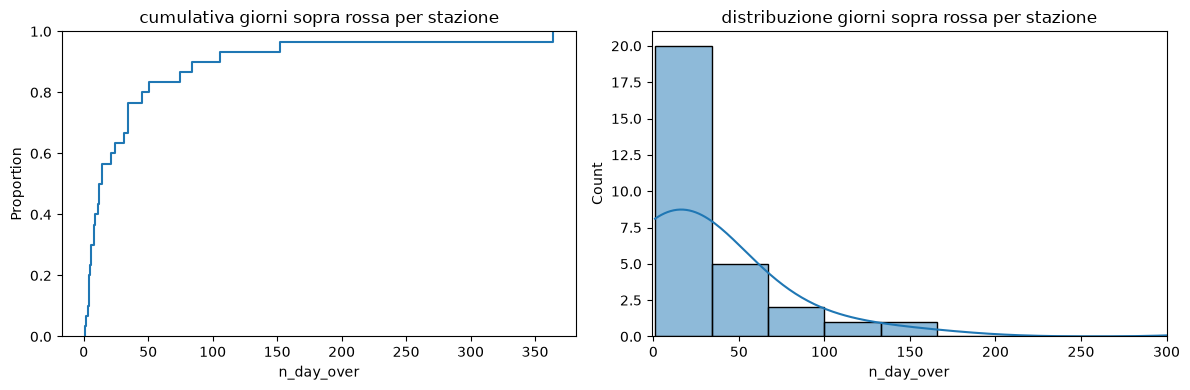

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.ecdfplot(data=stats_rosso, x='n_day_over', ax=ax[0])
sns.histplot(data=stats_rosso, x='n_day_over', kde=True, ax=ax[1])
ax[0].set(title='cumulativa giorni sopra rossa per stazione')
ax[1].set(title='distribuzione giorni sopra rossa per stazione', xlim=(-1, 300))
plt.tight_layout()
plt.show()

## 6. Serie temporali delle stazioni da verificare

Guardo la serie intera delle stazioni con molti giorni sopra rossa (Castrocaro, Ponte Vico, Teodorano, Alfonsine) e di Mezzano come confronto, con le linee di soglia_1 e soglia_2.

Serve a capire se i superamenti sono piene plausibili (salita, picco, rientro) o se ci sono salti del livello di base, plateau o picchi isolati che fanno pensare a problemi del sensore o a una soglia non coerente con la serie.

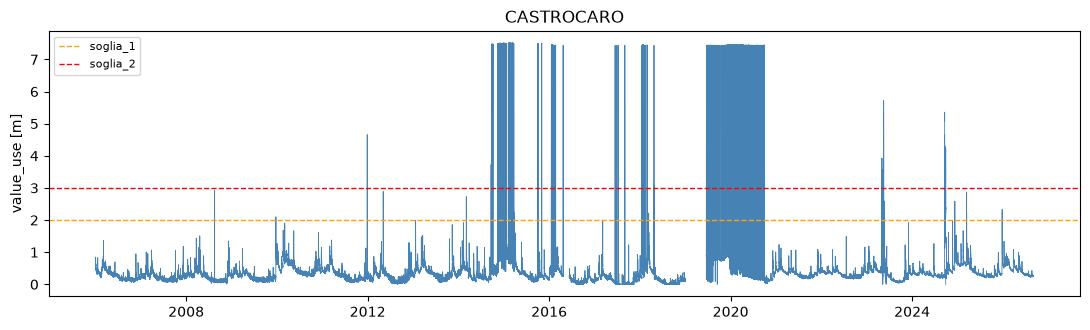

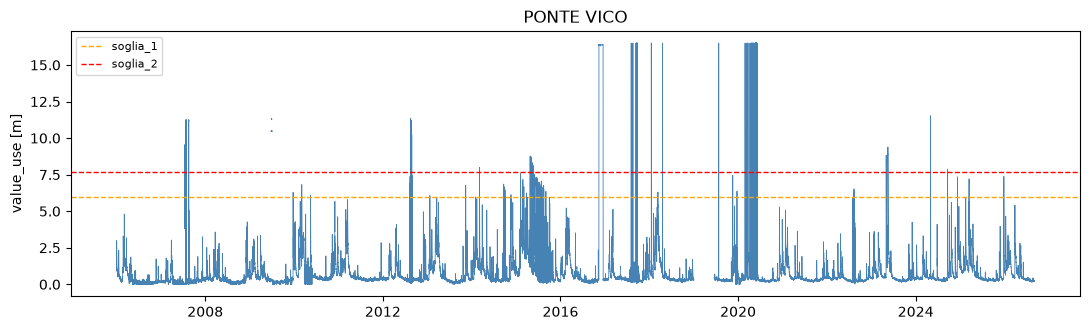

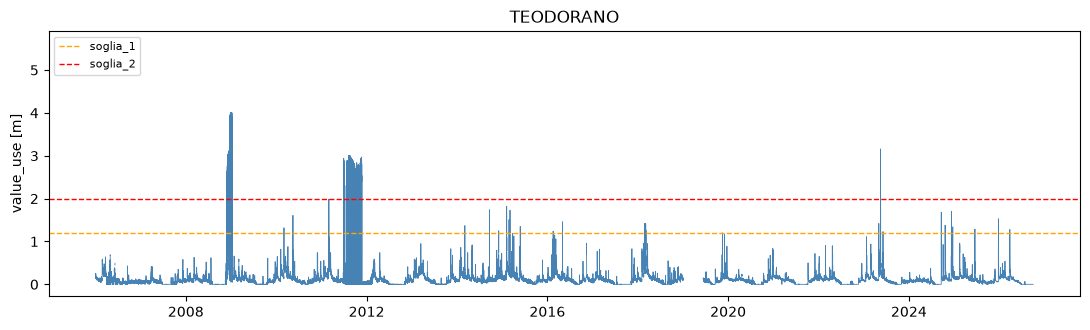

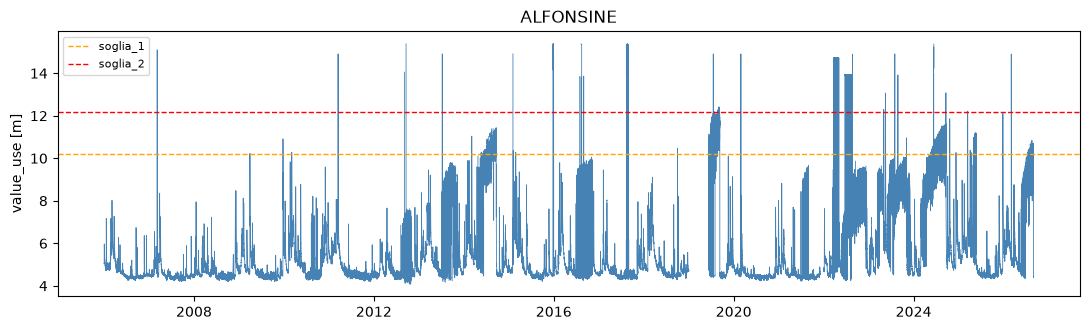

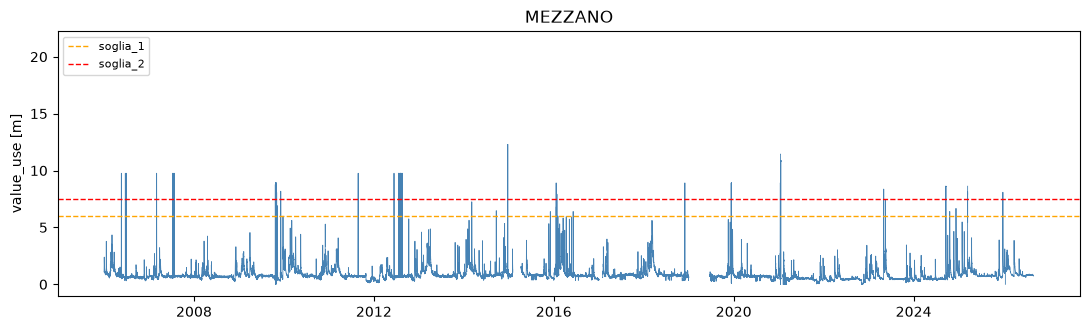

In [19]:
for stazione in ['CASTROCARO', 'PONTE VICO', 'TEODORANO', 'ALFONSINE', 'MEZZANO']:
    _ = idro.grafico_stazione(df=df_big_table_ready, stazione=stazione)
    plt.show()

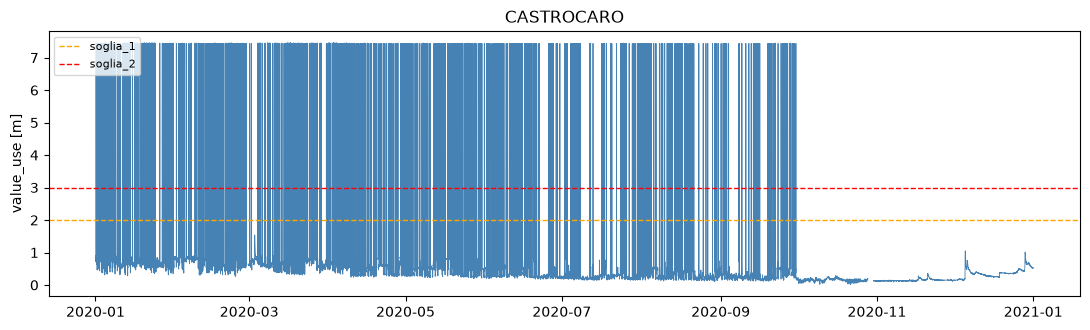

In [20]:
#zoom su un anno
_ = idro.grafico_stazione(df=df_big_table_ready[df_big_table_ready.index.year == 2020], stazione='CASTROCARO')
plt.show()

## 7. Distribuzioni di `xt` e `log(1+xt)`

Confronto le distribuzioni del livello normalizzato sulla soglia rossa, `xt = h/soglia_2`, e del suo log (`log 1+xt`), prima tutte le stazioni insieme e poi stazione per stazione (cumulativa e densità).

Anche dopo la normalizzazione le stazioni non hanno la stessa distribuzione: le cumulative per stazione sono spostate e con forme diverse. Il log comprime la coda ma non rende le stazioni uguali. Quindi la normalizzazione sulla soglia non basta da sola a rendere le stazioni confrontabili. Gli assi sono limitati a [0, 1], cioè al regime sotto rossa.

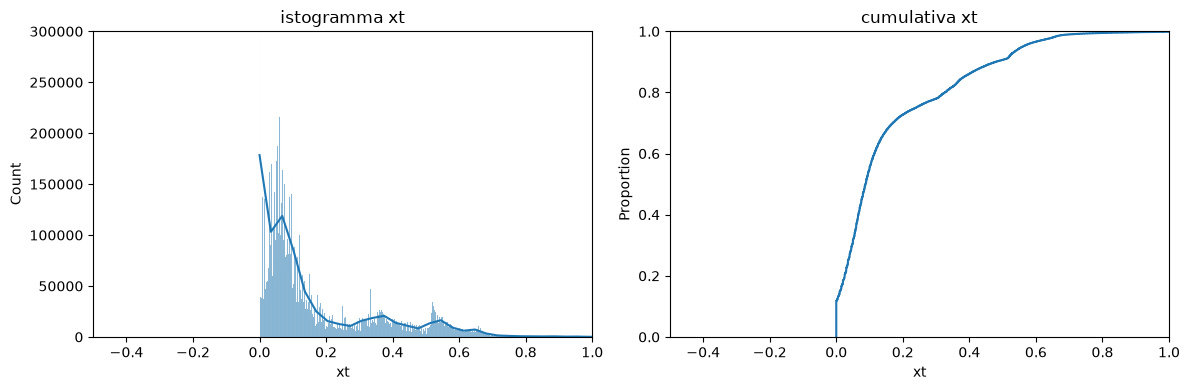

In [21]:
_ = idro.distribuzione_globale(df=df_big_table_ready, col='xt')
plt.show()

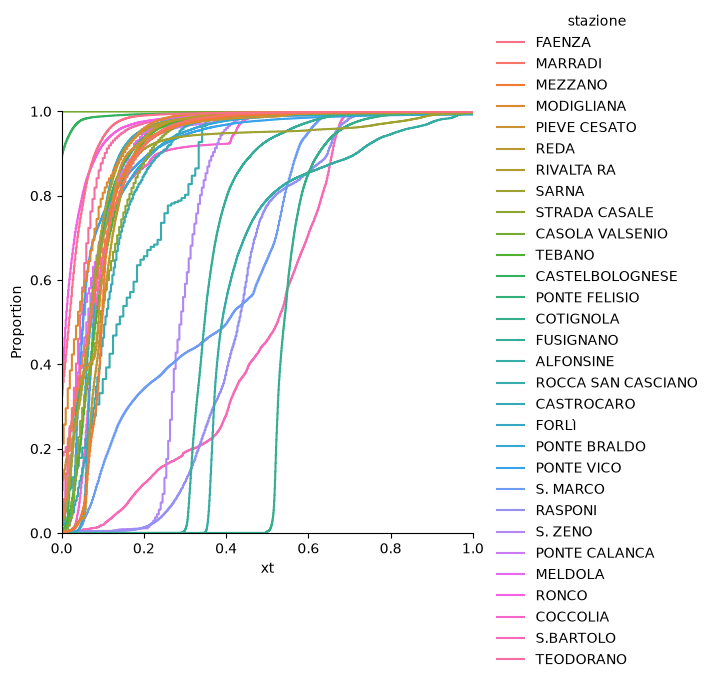

In [22]:
_ = idro.ecdf_per_stazione(df=df_big_table_ready, col='xt')
plt.show()

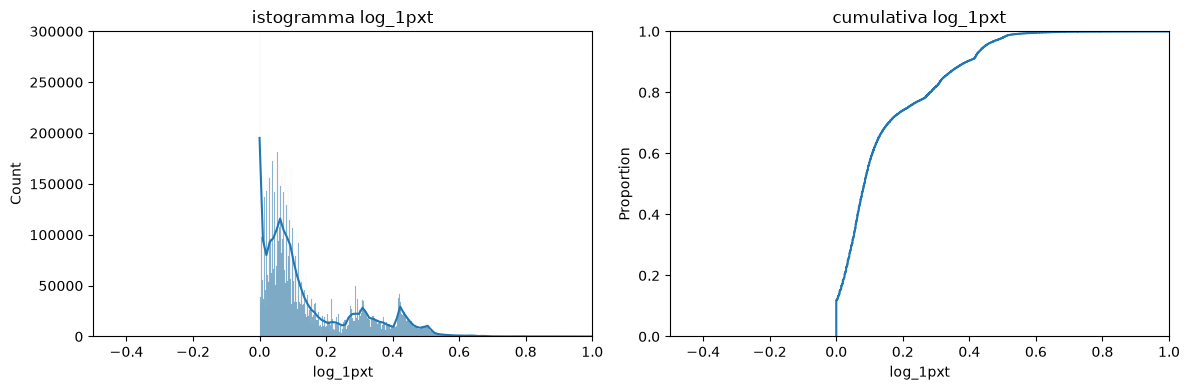

In [23]:
_ = idro.distribuzione_globale(df=df_big_table_ready, col='log_1pxt')
plt.show()

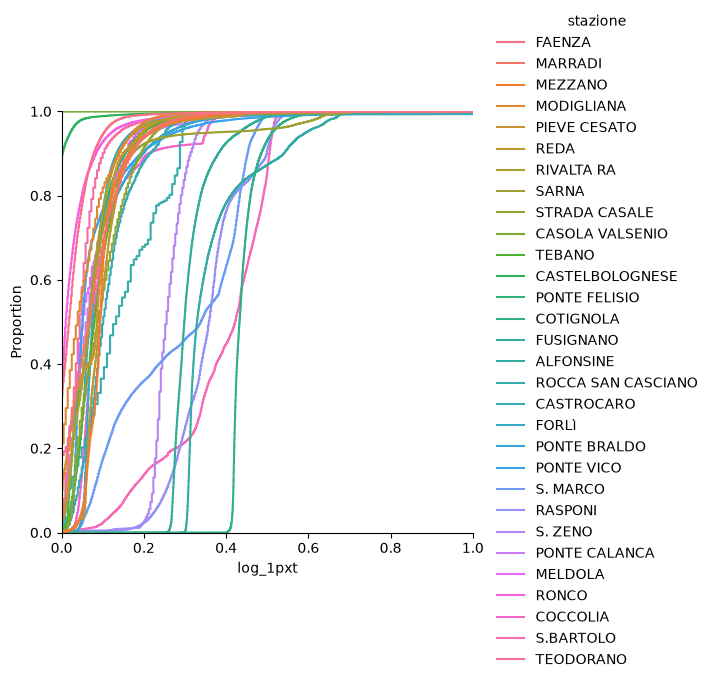

In [24]:
_ = idro.ecdf_per_stazione(df=df_big_table_ready, col='log_1pxt')
plt.show()

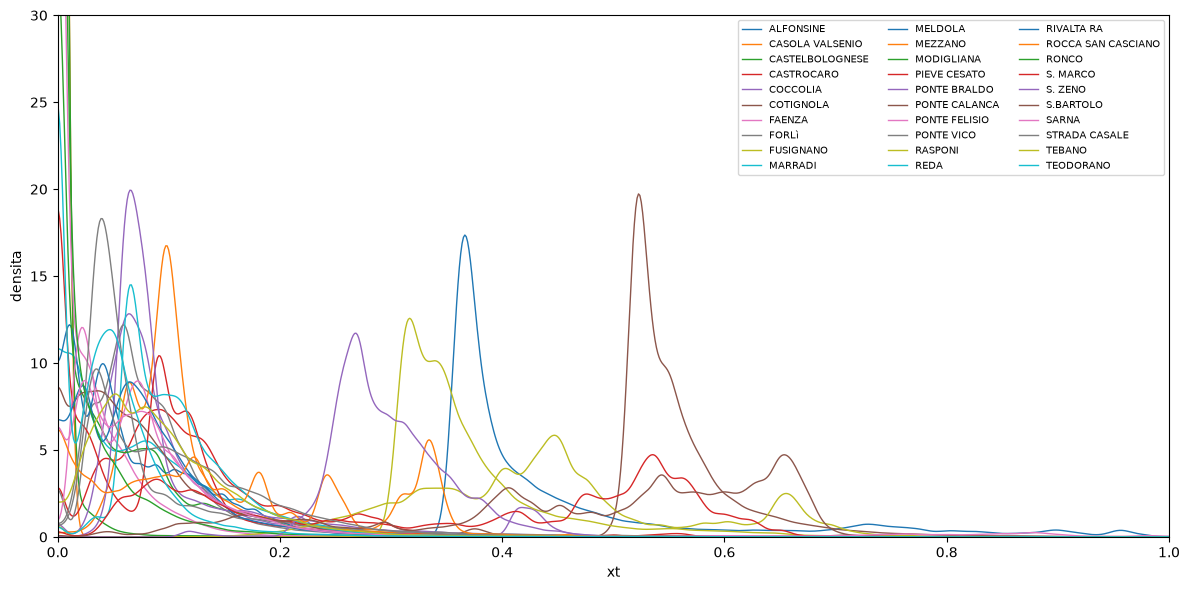

In [25]:
_ = idro.densita_per_stazione(df=df_big_table_ready, col='xt')
plt.show()

## 8. Giorni con più stazioni sopra rossa

Per ogni giorno conto quante e quali stazioni sono sopra rossa. Poi tengo i giorni con più di 5 stazioni, quelli con 3-5 e quelli con una sola stazione (escludendo Castrocaro, Ponte Vico e Teodorano come sensibilità).

Molti sono giorni consecutivi dello stesso episodio, quindi le finestre distinte sono meno degli 11 giorni. La maggior parte dei giorni rossi resta invece con una sola stazione.

In [26]:
per_giorno = idro.stazioni_per_giorno(df_stats_over=df_all_stats_over, livello=2)
#
per_giorno.query('n_stazioni>5').sort_index()

,n_stazioni,stazioni
d_date,,
2014-09-20,10,"[CASOLA VALSENIO, CASTROCARO, FAENZA, MARRADI,..."
2019-05-13,8,"[COTIGNOLA, FORLì, PIEVE CESATO, PONTE BRALDO,..."
2023-05-02,7,"[CASTROCARO, FAENZA, PIEVE CESATO, PONTE BRALD..."
2023-05-03,14,"[ALFONSINE, CASTELBOLOGNESE, CASTROCARO, COTIG..."
2023-05-16,19,"[CASOLA VALSENIO, CASTELBOLOGNESE, CASTROCARO,..."
2023-05-17,23,"[ALFONSINE, CASTELBOLOGNESE, CASTROCARO, COCCO..."
2023-05-18,11,"[COCCOLIA, COTIGNOLA, FAENZA, PONTE BRALDO, PO..."
2024-09-18,9,"[CASOLA VALSENIO, CASTELBOLOGNESE, CASTROCARO,..."
2024-09-19,15,"[ALFONSINE, CASTELBOLOGNESE, CASTROCARO, COTIG..."


In [27]:
per_giorno.query('n_stazioni<=5 & n_stazioni>2').sort_index()

,n_stazioni,stazioni
d_date,,
2014-03-05,3,"[COTIGNOLA, PONTE VICO, TEBANO]"
2019-07-25,3,"[CASTROCARO, PONTE BRALDO, PONTE VICO]"
2022-07-19,3,"[ALFONSINE, CASTELBOLOGNESE, MODIGLIANA]"
2022-07-20,3,"[ALFONSINE, CASTELBOLOGNESE, MODIGLIANA]"
2025-12-25,5,"[COTIGNOLA, MEZZANO, PIEVE CESATO, RIVALTA RA,..."
2025-12-26,4,"[COTIGNOLA, FUSIGNANO, MEZZANO, PIEVE CESATO]"


In [28]:
escludi = ['CASTROCARO', 'PONTE VICO', 'TEODORANO']
#
per_giorno[(per_giorno.n_stazioni == 1)
           & (per_giorno.stazioni.apply(lambda x: all(k not in x for k in escludi)))].sort_index()

,n_stazioni,stazioni
d_date,,
2006-07-21,1,[RIVALTA RA]
2007-08-14,1,[REDA]
2008-07-31,1,[RIVALTA RA]
2008-08-01,1,[RIVALTA RA]
2008-08-02,1,[RIVALTA RA]
...,...,...
2024-10-20,1,[COTIGNOLA]
2025-04-30,1,[TEBANO]
2025-05-01,1,[TEBANO]


## 9. Cross-correlazione tra stazioni

Porto tutte le serie di `xt` a 15 minuti e, per ogni coppia, provo ritardi tra −48 h e +48 h tenendo quello con la correlazione più alta. Uso solo gli istanti in cui ci sono entrambe le misure e scarto le coppie con meno di `min_n` punti in comune (equivalente a un mese a 15 min, ma non è un mese continuo). Ritardo positivo = `st2` anticipa `st1`.

Le coppie sullo stesso corso d'acqua hanno correlazioni molto alte.
I ritardi sono indicativi: nel periodo a 30 minuti metà dei quarti d'ora sono vuoti, quindi il numero di punti cambia con il ritardo.

In [ ]:
coppie = cross_corr_stazioni(df=df_big_table_ready, col='xt', passo=15, max_ore=48, min_n=4 * 24 * 30)
coppie

In [34]:
#coppie.to_excel(storage_xlsx_corr, index=False)
coppie = pd.read_excel(storage_xlsx_corr)

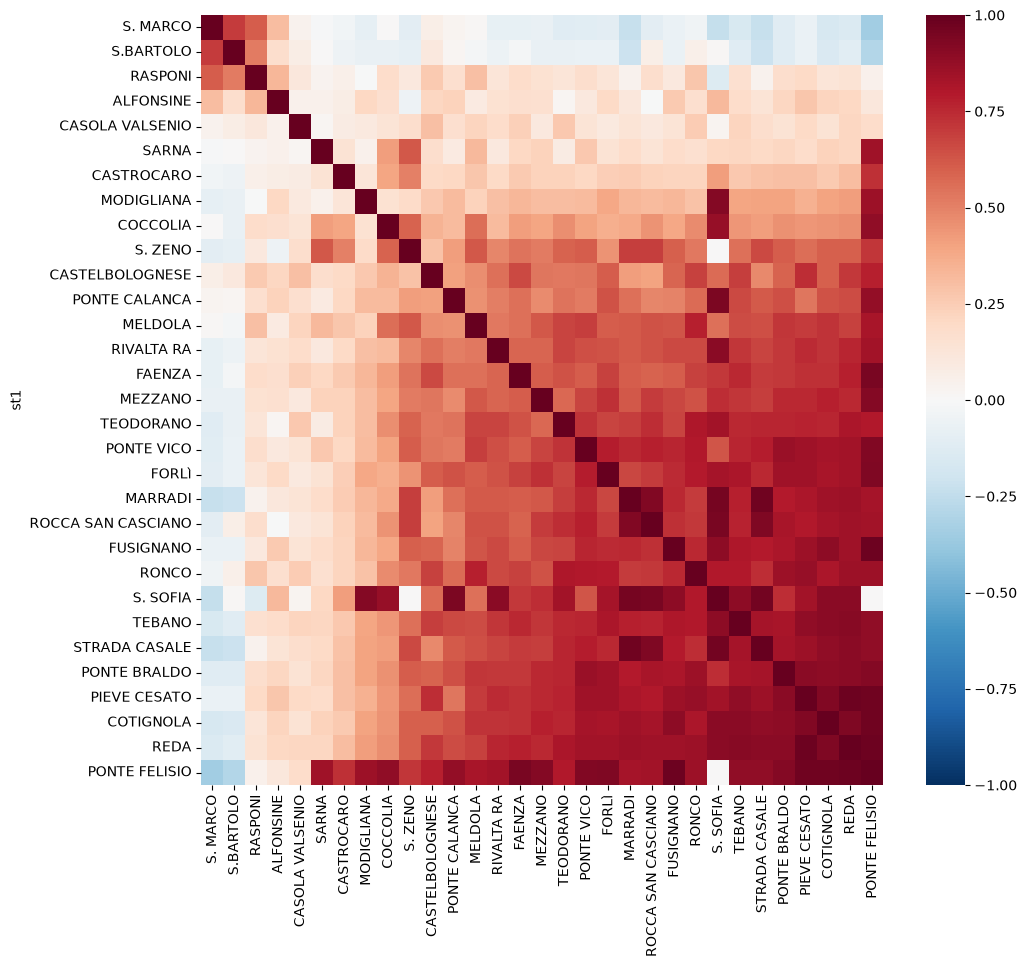

In [37]:
C_corr = idro.matrice_corr(coppie=coppie)
#
_ = idro.heatmap_corr(C=C_corr, file_png='heatmap_correlazioni.png')
plt.show()

## 10. Contesto valido prima del primo rosso giornaliero

Per ogni stazione-giorno sopra rossa prendo il primo timestamp sopra soglia_2 e conto quante misure valide consecutive ci sono prima, tornando indietro fino al primo `NaN` (anche attraversando la mezzanotte). Il conteggio si ferma anche se nella griglia c'è un buco di timestamp più lungo di 30 minuti.

`d_date` (giorno italiano) e almeno 3 misure sopra soglia nel giorno, cioè lo stesso criterio di `over_s_analysis`. Così i giorni coincidono con quelli della sezione 5 (controllo con `confronto_giorni`: la colonna `differenza` deve essere 0).

`n_validi_prima` = numero di misure (step), `ore_contesto` = durata effettiva calcolata dai timestamp. Tengo tutti e due perché lo stesso numero di step vale 12 h a 30 min e 6 h a 15 min. `step_ts` dice in che regime cade il superamento.

In [39]:
contesto_rosso = idro.contesto_prima_soglia(df=df_big_table_ready, soglia='soglia_2', min_campioni=3)
#
idro.confronto_giorni(df_stats_over=df_all_stats_over, contesto=contesto_rosso, livello=2)

,giorni_over_s_analysis,giorni_contesto,differenza
stazione,,,
ALFONSINE,84,84,0
CASOLA VALSENIO,4,4,0
CASTELBOLOGNESE,9,9,0
CASTROCARO,364,364,0
COCCOLIA,8,8,0
COTIGNOLA,14,14,0
FAENZA,12,12,0
FORLì,4,4,0
FUSIGNANO,4,4,0


In [41]:
contesto_rosso.sort_values(['stazione', 'd_date'])

,stazione,d_date,primo_superamento,step_ts,n_validi_prima,inizio_contesto,ore_contesto
0,ALFONSINE,2015-12-24,2015-12-24 19:30:00+00:00,30.0,4147,2015-09-29 10:00:00+00:00,2073.50
1,ALFONSINE,2015-12-25,2015-12-24 23:00:00+00:00,30.0,4154,2015-09-29 10:00:00+00:00,2077.00
2,ALFONSINE,2015-12-26,2015-12-25 23:30:00+00:00,30.0,0,NaT,0.00
3,ALFONSINE,2015-12-27,2015-12-26 23:00:00+00:00,30.0,1,2015-12-26 22:30:00+00:00,0.50
4,ALFONSINE,2015-12-28,2015-12-27 23:00:00+00:00,30.0,4,2015-12-27 21:00:00+00:00,2.00
...,...,...,...,...,...,...,...
1173,TEODORANO,2019-02-28,2019-02-28 01:30:00+00:00,15.0,0,NaT,0.00
1174,TEODORANO,2019-03-01,2019-03-01 05:30:00+00:00,15.0,0,NaT,0.00
1175,TEODORANO,2019-03-02,2019-03-02 02:30:00+00:00,15.0,0,NaT,0.00
1176,TEODORANO,2023-05-16,2023-05-16 08:30:00+00:00,15.0,25349,2022-08-25 07:15:00+00:00,6337.25


In [42]:
contesto_arancione = idro.contesto_prima_soglia(df=df_big_table_ready, soglia='soglia_1', min_campioni=3)
contesto_arancione.sort_values(['stazione', 'd_date'])

,stazione,d_date,primo_superamento,step_ts,n_validi_prima,inizio_contesto,ore_contesto
0,ALFONSINE,2009-03-30,2009-03-30 09:30:00+00:00,30.0,4552,2008-12-25 13:30:00+00:00,2276.00
1,ALFONSINE,2009-12-23,2009-12-23 16:30:00+00:00,30.0,384,2009-12-15 16:30:00+00:00,192.00
2,ALFONSINE,2009-12-24,2009-12-23 23:00:00+00:00,30.0,397,2009-12-15 16:30:00+00:00,198.50
3,ALFONSINE,2010-03-05,2010-03-04 23:30:00+00:00,30.0,1096,2010-02-10 03:30:00+00:00,548.00
4,ALFONSINE,2014-03-05,2014-03-05 11:00:00+00:00,30.0,1236,2014-02-07 17:00:00+00:00,618.00
...,...,...,...,...,...,...,...
2725,TEODORANO,2024-10-19,2024-10-19 20:15:00+00:00,15.0,5763,2024-08-20 19:30:00+00:00,1440.75
2726,TEODORANO,2024-12-09,2024-12-09 11:30:00+00:00,15.0,10624,2024-08-20 19:30:00+00:00,2656.00
2727,TEODORANO,2025-06-17,2025-06-17 11:00:00+00:00,15.0,5054,2025-04-25 19:30:00+00:00,1263.50
2728,TEODORANO,2025-12-24,2025-12-24 08:30:00+00:00,15.0,2236,2025-12-01 01:30:00+00:00,559.00


### 10.1 Boxplot e riepilogo

Boxplot per stazione degli step validi prima del primo rosso giornaliero (intero e zoom a 500 step), poi lo stesso in ore, poi la tabella riassuntiva con quartili degli step, mediana delle ore e percentuale di giorni con almeno 1, 3, 6, 12, 24 ore di contesto.

Nella prima versione (prima della correzione dei giorni) quasi tutte le stazioni avevano almeno 6 ore di contesto continuo in oltre l'80–90% dei giorni rossi. Fa eccezione Alfonsine: in molti giorni non c'è nessuna misura valida subito prima del rosso (mediana 0 ore), da verificare se dipende da un campionamento più rado della griglia o da buchi reali. Anche Ponte Calanca ha contesti corti (mediana ~5 h). I valori vanno riletti dopo la correzione.

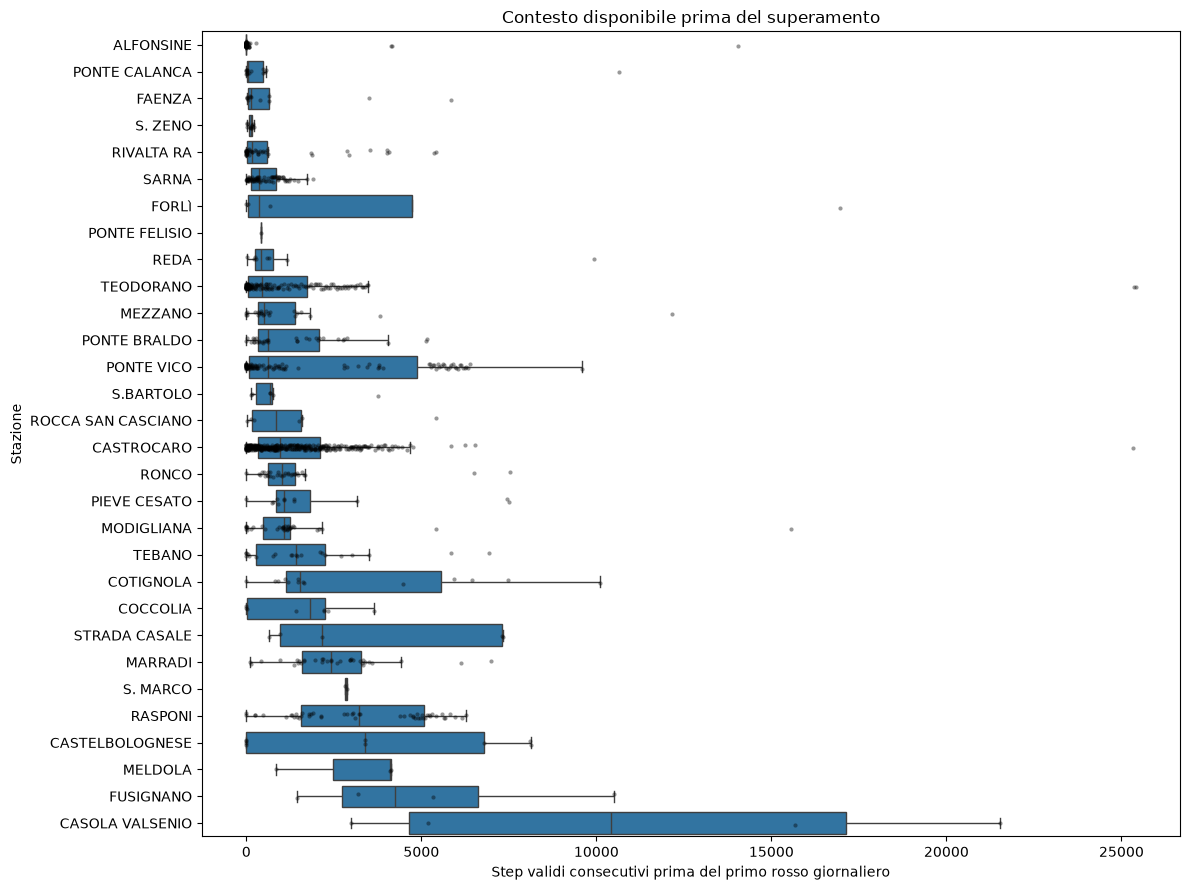

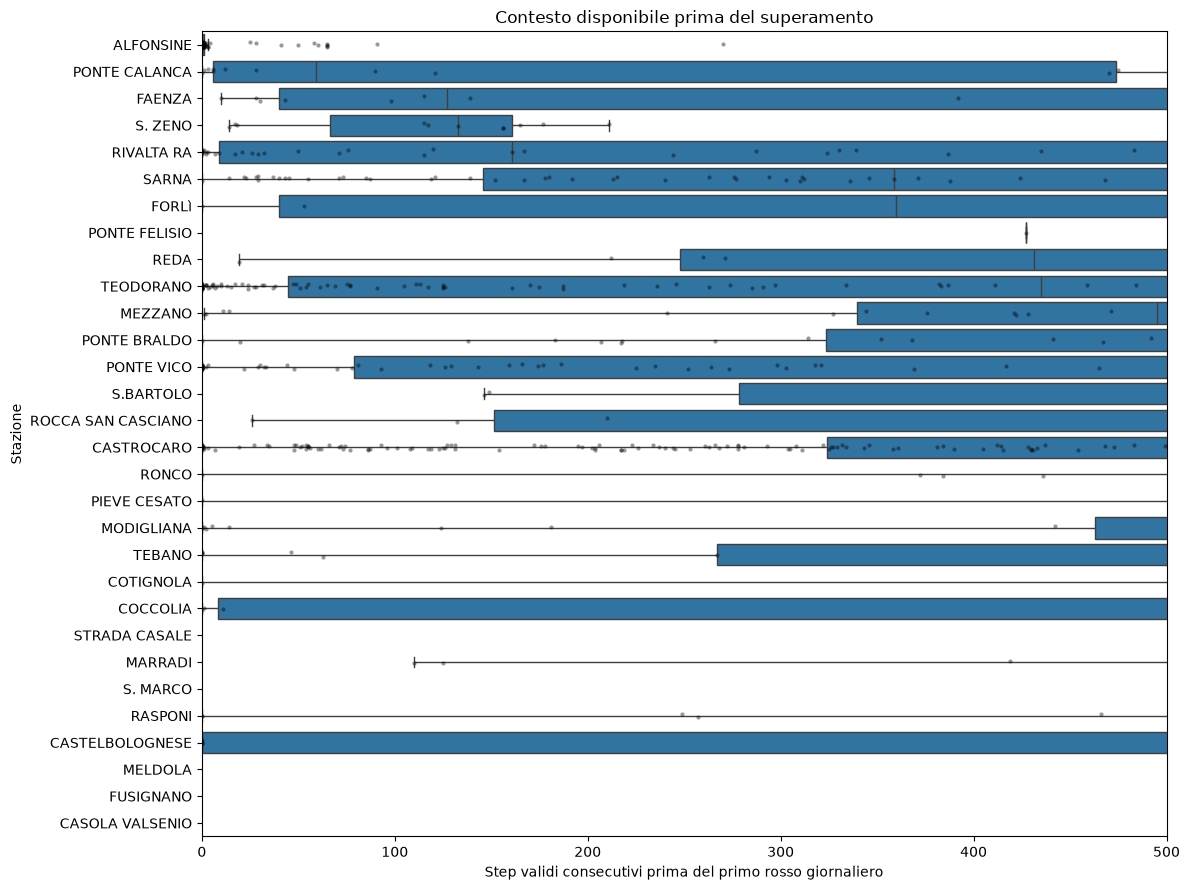

In [43]:
_ = idro.boxplot_contesto(contesto=contesto_rosso, col='n_validi_prima')
plt.show()
#
_ = idro.boxplot_contesto(contesto=contesto_rosso, col='n_validi_prima', xlim=(0, 500))
plt.show()

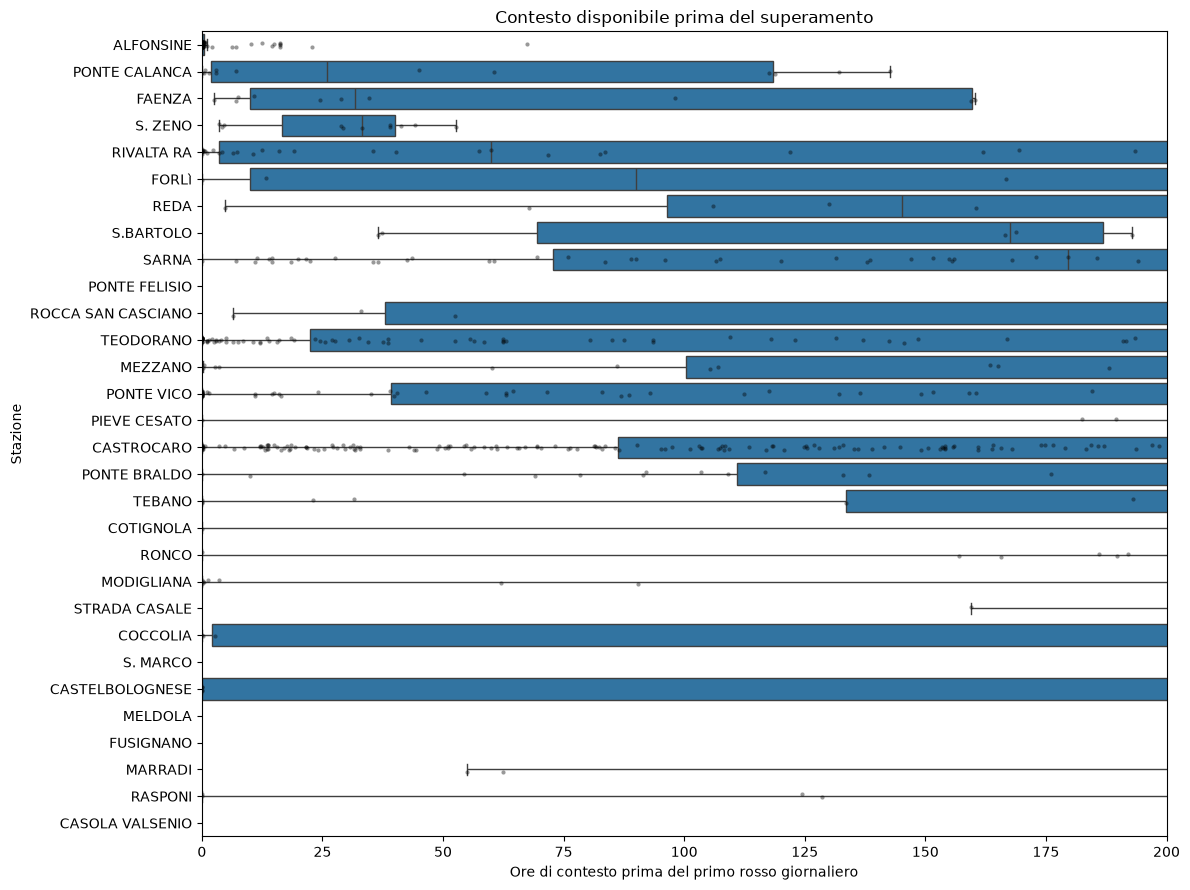

In [44]:
_ = idro.boxplot_contesto(contesto=contesto_rosso, col='ore_contesto', xlim=(0, 200),
                     xlabel='Ore di contesto prima del primo rosso giornaliero')
plt.show()

In [45]:
riepilogo_rosso = idro.riepilogo_contesto(contesto=contesto_rosso)
riepilogo_rosso

,giorni,senza_contesto,q25_step,mediana_step,q75_step,mediana_ore,pct_almeno_1h,pct_almeno_3h,pct_almeno_6h,pct_almeno_12h,pct_almeno_24h
stazione,,,,,,,,,,,
ALFONSINE,84,51,0.0,0.0,1.2,0.0,20.2,17.9,17.9,14.3,4.8
CASOLA VALSENIO,4,0,4636.0,10427.5,17138.2,2707.8,100.0,100.0,100.0,100.0,100.0
CASTELBOLOGNESE,9,4,0.0,3394.0,6782.0,848.5,55.6,55.6,55.6,55.6,55.6
CASTROCARO,364,11,324.2,968.0,2092.2,302.2,96.2,96.2,95.6,95.1,88.7
COCCOLIA,8,1,8.5,1809.5,2251.0,554.1,75.0,62.5,62.5,62.5,62.5
COTIGNOLA,14,1,1124.8,1543.5,5560.2,385.9,92.9,92.9,92.9,92.9,92.9
FAENZA,12,0,39.8,127.0,638.8,31.8,100.0,91.7,91.7,66.7,66.7
FORLì,4,1,39.8,360.0,4738.8,90.0,75.0,75.0,75.0,75.0,50.0
FUSIGNANO,4,0,2746.2,4253.0,6621.8,1063.2,100.0,100.0,100.0,100.0,100.0


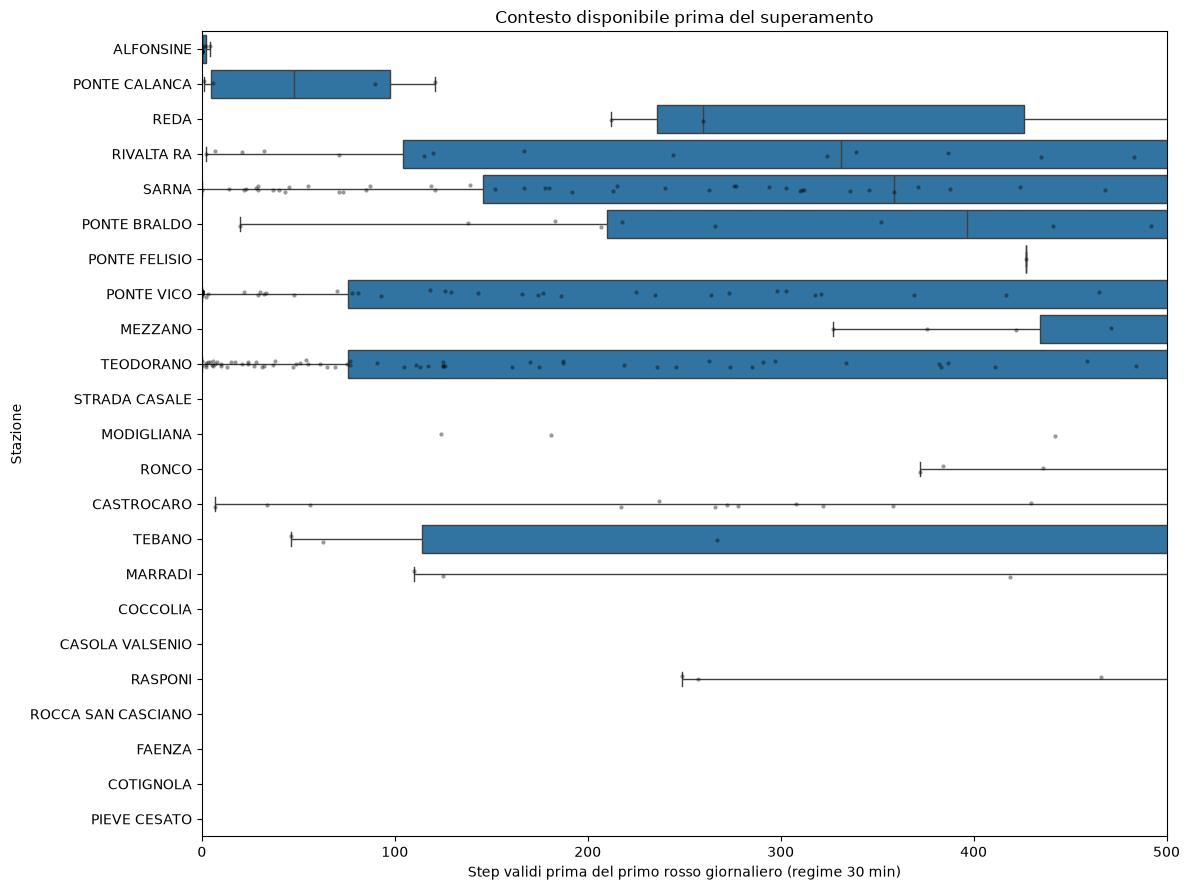

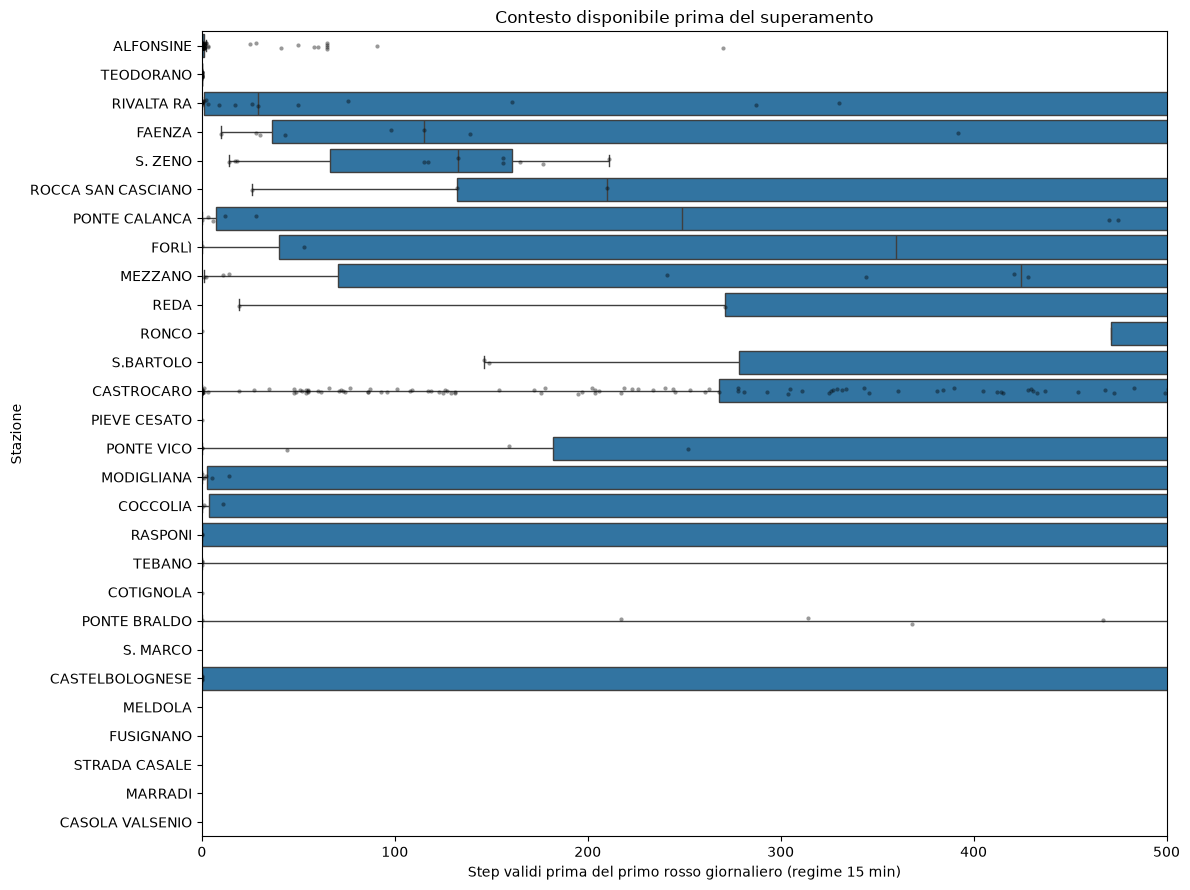

In [46]:
#stesso boxplot separato per regime di campionamento
for step in [30, 15]:
    _ = idro.boxplot_contesto(contesto=contesto_rosso[contesto_rosso.step_ts == step], col='n_validi_prima', xlim=(0, 500),
                         xlabel=f'Step validi prima del primo rosso giornaliero (regime {step} min)')
    plt.show()

## 11. Aree di copertura per la richiesta SAR

Per ogni giorno con più di 5 stazioni sopra rossa prendo le coordinate delle stazioni, le porto in UTM e calcolo rettangolo e quadrato che le contengono, con 1 km di margine. La riga `TUTTE_LE_DATE` è l'unione di tutte le stazioni coinvolte almeno una volta.


In [47]:
geo, aree, coperture = idro.aree_copertura(per_giorno=per_giorno, df_anag=df_anag, min_stazioni=5, margine_km=1)
#
aree.round(2)

stazioni senza coordinate:
 Empty DataFrame
Columns: [data, stazione]
Index: []


,data,n_stazioni_localizzate,corsi,larghezza_km,altezza_km,rettangolo_km2,lato_quadrato_km,quadrato_km2
0,2014-09-20,10,"F.LAMONE, F.MONTONE, F.SENIO, T.MARZENO",28.50,27.76,791.13,28.50,812.06
1,2019-05-13,8,"F.LAMONE, F.MONTONE, F.RONCO, F.SENIO, T.MARZENO",26.61,21.57,574.02,26.61,708.23
2,2023-05-02,7,"F.LAMONE, F.MONTONE, F.RABBI, F.SENIO, T.MARZENO",20.61,23.09,475.98,23.09,533.33
3,2023-05-03,14,"F.LAMONE, F.MONTONE, F.RABBI, F.SENIO, T.MARZENO",25.19,39.89,1004.90,39.89,1591.06
4,2023-05-16,19,"F.LAMONE, F.MONTONE, F.RABBI, F.RONCO, F.SENIO...",44.55,32.97,1468.98,44.55,1984.87
5,2023-05-17,23,"F.LAMONE, F.MONTONE, F.RABBI, F.RONCO, F.SENIO...",46.74,51.81,2421.22,51.81,2683.84
6,2023-05-18,11,"F.LAMONE, F.MONTONE, F.RABBI, F.RONCO, F.SENIO...",40.66,28.37,1153.50,40.66,1653.39
7,2024-09-18,9,"F.LAMONE, F.MONTONE, F.RABBI, F.SENIO, T.MARZENO",32.39,27.22,881.73,32.39,1048.93
8,2024-09-19,15,"F.LAMONE, F.MONTONE, F.SENIO, T.MARZENO",25.19,39.37,991.75,39.37,1549.69
9,2025-03-14,8,"F.LAMONE, F.MONTONE, F.RONCO",45.50,48.10,2188.25,48.10,2313.23


### 11.1 Mappe

 Mappa con le stazioni colorate per corso d'acqua, rettangolo blu e quadrato rosso; nel riquadro in alto le dimensioni. Prima tutte le date insieme, poi un giorno singolo (cambio `data` con una delle date di `aree`).


In [53]:
m = idro.mappa_copertura(geo=geo, aree=aree, coperture=coperture, carto_key=CARTO_KEY, data='TUTTE_LE_DATE')
m

In [50]:
m = idro.mappa_copertura(geo=geo, aree=aree, coperture=coperture, carto_key=CARTO_KEY, data='2023-05-17')
m